In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [10]:
N = 1000
k = 10
ps = [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1]
seed = 321

def avg_path_length(G):
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    H = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return nx.average_shortest_path_length(H)

G0 = nx.watts_strogatz_graph(N, k, 0, seed=seed)
C0 = nx.average_clustering(G0)
L0 = avg_path_length(G0)
D0 = nx.diameter(G0)
print("WS p=0")
print("  Avg clustering:", C0)
print("  Avg path length:", L0)
print("  Diameter:", D0)

WS p=0
  Avg clustering: 0.6666666666666666
  Avg path length: 50.450450450450454
  Diameter: 100


In [11]:
Cs, Ls = [], []
for p in ps:
    G = nx.watts_strogatz_graph(N, k, p, seed=seed)
    Cs.append(nx.average_clustering(G))
    Ls.append(avg_path_length(G))

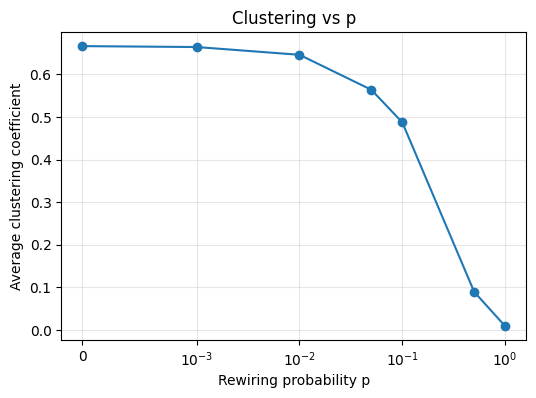

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(ps, Cs, marker="o")
plt.xscale("symlog", linthresh=1e-3)
plt.xlabel("Rewiring probability p")
plt.ylabel("Average clustering coefficient")
plt.title("Clustering vs p")
plt.grid(True, alpha=0.3)
plt.show()

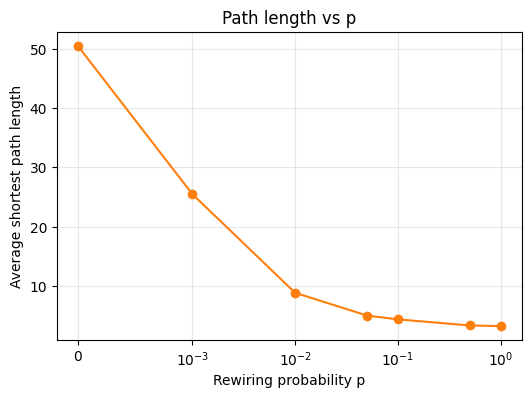

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(ps, Ls, marker="o", color="tab:orange")
plt.xscale("symlog", linthresh=1e-3)
plt.xlabel("Rewiring probability p")
plt.ylabel("Average shortest path length")
plt.title("Path length vs p")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
p_er = k / (N - 1)
Ger = nx.erdos_renyi_graph(N, p_er, seed=seed)
Cer = nx.average_clustering(Ger)
Ler = avg_path_length(Ger)

print("  p_er:", p_er)
print("  Avg clustering:", Cer)
print("  Avg path length:", Ler)


ER (same N, same expected avg degree)
  p_er: 0.01001001001001001
  Avg clustering: 0.009945714253067195
  Avg path length: 3.2635555555555555


In [9]:
print("\nAnswer:")
print("  High clustering + low path length: typically small p, around ~0.001 to 0.05.")
print("  Why small randomness reduces path length: a few rewired edges create long-range shortcuts,")
print("  connecting distant parts of the ring and rapidly shrinking distances, while clustering stays high initially.")


Answer:
  High clustering + low path length: typically small p, around ~0.001 to 0.05.
  Why small randomness reduces path length: a few rewired edges create long-range shortcuts,
  connecting distant parts of the ring and rapidly shrinking distances, while clustering stays high initially.
